In [1]:
from google.colab import output
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

In [ ]:
output.enable_custom_widget_manager()
# !pip install -q ipympl

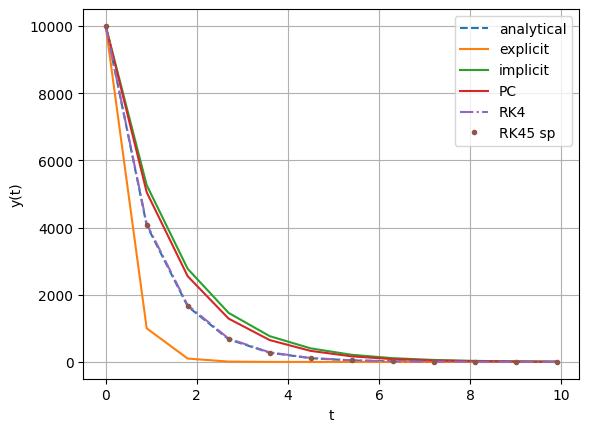

In [21]:
# %matplotlib widget

dt = 0.9
end_time = 10
y0 = 10000
lamda = -1.0
t_array = np.arange(0, end_time, dt)
timesteps = np.size(t_array)

y_exp = np.zeros(timesteps)
y_imp = np.zeros(timesteps)
y_pc = np.zeros(timesteps)
y_rk4 = np.zeros(timesteps)
y_exp[0] = y0
y_imp[0] = y0
y_pc[0] = y0
y_rk4[0] = y0
for t in range(timesteps-1):
    y_exp[t+1] = y_exp[t]*(1 + lamda*dt) # explicit scheme
    y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme

    # Predictor-Corrector (Heun)
    y_tilde = y_pc[t] + dt*lamda*y_pc[t]
    slope_avg = ( lamda*y_pc[t] + lamda*y_tilde )/2.0
    y_pc[t+1] = y_pc[t] + dt*slope_avg

    # RK4
    k1 = lamda*y_rk4[t]
    k2 = lamda*(y_rk4[t] + dt*k1/2.0)
    k3 = lamda*(y_rk4[t] + dt*k2/2.0)
    k4 = lamda*(y_rk4[t] + dt*k3)
    y_rk4[t+1] = y_rk4[t] + (k1 + 2*k2 + 2*k3 + k4)*dt/6.0

    # RK4 scipy
    y_rk4_sp = solve_ivp(fun=dydt, t_span=(0, end_time), y0=np.array([y0]), method='RK45', t_eval=t_array)


y_ana = y0*np.exp(lamda*t_array)

plt.close('all')
plt.plot(t_array, y_ana, '--', label='analytical')
plt.plot(t_array, y_exp, label='explicit')
plt.plot(t_array, y_imp, label='implicit')
plt.plot(t_array, y_pc, label='PC')
plt.plot(t_array, y_rk4, '-.', label='RK4')
plt.plot(y_rk4_sp.t, y_rk4_sp.y.squeeze(), '.', label='RK45 sp')



plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

In [15]:
y_rk4_sp.y

array([[1.00000000e+04, 4.06719362e+03, 1.65467072e+03, 6.73101668e+02,
        2.73809034e+02, 1.11380737e+02, 4.53071246e+01, 1.84295921e+01,
        7.49649960e+00, 3.04928222e+00, 1.24031940e+00, 5.04537676e-01]])

In [19]:
def dydt(t, y):
    return lamda*y

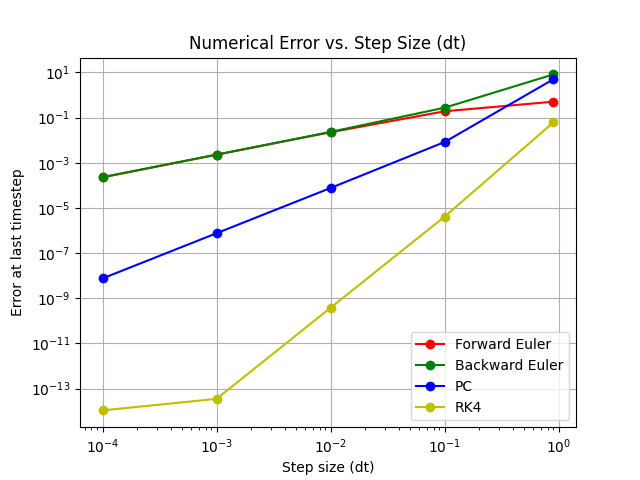

In [ ]:
dt = 0.9
end_time = 10
y0 = 10000
lamda = -1.0

# Range of dt values
dt_values = [0.9, 0.1, 0.01, 0.001, 0.0001]
errors = []
errors = {'exp': [], 'imp': [], 'pc': [], 'rk4': []}

for dt in dt_values:
    t_array = np.arange(0, end_time+0.000001, dt)
    y_exp = np.zeros(len(t_array))
    y_exp[0] = y0
    y_imp = y_exp.copy()
    y_pc = y_exp.copy()
    y_rk4 = y_exp.copy()

    # integration
    for t in range(len(t_array) - 1):
        y_exp[t + 1] = y_exp[t] * (1 + lamda * dt) # explicit scheme
        y_imp[t+1] = y_imp[t]/(1 - lamda*dt) # implicit scheme
        # Predictor-Corrector (Heun)
        y_tilde = y_pc[t] + dt*lamda*y_pc[t]
        slope_avg = ( lamda*y_pc[t] + lamda*y_tilde )/2.0
        y_pc[t+1] = y_pc[t] + dt*slope_avg
        # RK4 solution
        k1 = lamda*y_rk4[t]
        k2 = lamda*(y_rk4[t] + dt*k1/2.0)
        k3 = lamda*(y_rk4[t] + dt*k2/2.0)
        k4 = lamda*(y_rk4[t] + dt*k3)
        y_rk4[t+1] = y_rk4[t] + (k1 + 2*k2 + 2*k3 + k4)*dt/6.0

    # Exact analytical solution at end_time
    y_exact = y0 * np.exp(lamda * t_array[-1])

    # Absolute global error at the final time step
    err = np.abs(y_exact - y_exp[-1])
    errors['exp'].append(err)
    err = np.abs(y_exact - y_imp[-1])
    errors['imp'].append(err)
    err = np.abs(y_exact - y_pc[-1])
    errors['pc'].append(err)
    err = np.abs(y_exact - y_rk4[-1])
    errors['rk4'].append(err)

# Plotting Error vs dt
plt.close('all')
plt.figure()
plt.loglog(dt_values, errors['exp'], "ro-", label="Forward Euler")
plt.loglog(dt_values, errors['imp'], "go-", label="Backward Euler")
plt.loglog(dt_values, errors['pc'], "bo-", label="PC")
plt.loglog(dt_values, errors['rk4'], "yo-", label="RK4")

# plt.gca().set_aspect('equal')
plt.xlabel("Step size (dt)")
plt.ylabel("Error at last timestep")
plt.title("Numerical Error vs. Step Size (dt)")
plt.grid(True)
plt.legend()
plt.show()